# Model Initialization - Package

This notebook initializes one dynamic Modelica model that belongs to a package, from its auxiliary package.

It loads the package and its auxiliary from `models/`, simulates the auxiliary to compute the initialization values, applies them to a copy of the package, and saves the initialized package to `outputs/`.

In [1]:
include("../scripts/dictionaries.jl")
include("../scripts/helpers.jl")
using .WorkflowHelpers
using OMJulia
using Plots, DataFrames, CSV

# --- Configuration ---

# 1. Root dynamic model to initialize (qualified package name)
MODEL = "Demo_IEEE14.IEEE14DisconnectLine"

# 2. Input and output directories
MODELS_DIR = abspath("models")
OUTPUT_DIR = abspath("outputs")
mkpath(OUTPUT_DIR)

# 3. Derived package/model names and paths
SOURCE_PACKAGE = split(MODEL, ".")[1]
MODEL_DIR = joinpath(MODELS_DIR, SOURCE_PACKAGE)
PATHS = package_workflow_paths(MODEL, MODEL_DIR, OUTPUT_DIR)

MODELS_PKG_PATH = PATHS.source_package_file

# Auxiliary package (input, from BuildAux) lives under models/
AUX_PACKAGE = PATHS.aux_package
AUX_ROOT_MODEL = PATHS.aux_root_model
AUX_DIR = joinpath(MODELS_DIR, AUX_PACKAGE)
AUX_PACKAGE_FILE = joinpath(AUX_DIR, "package.mo")

# Initialized package (output) is written under outputs/
INITIALIZED_PACKAGE = PATHS.initialized_package
INITIALIZED_DIR = PATHS.initialized_dir
INITIALIZED_ROOT_MODEL = PATHS.initialized_root_model
INITIALIZED_PACKAGE_FILE = PATHS.initialized_package_file
INITIALIZED_ORDER_FILE = PATHS.initialized_order_file

# 4. Output directory for OpenModelica build artifacts
RUN_OUTPUT_DIR = joinpath(OUTPUT_DIR, INITIALIZED_PACKAGE * "_outputs")
mkpath(RUN_OUTPUT_DIR)

# 5. Library paths
# Modelica Standard Library
OMLIB_DIR = joinpath(homedir(), ".openmodelica", "libraries")
ENV["OPENMODELICALIBRARY"] = OMLIB_DIR
MODELICA_PKG_PATH = joinpath(OMLIB_DIR, "Modelica 3.2.3+maint.om", "package.mo")
# Dynawo Modelica library from this repo
DYNAWO_PKG_PATH = abspath("../dynawo_library/Dynawo/package.mo")

# 6. INIT model selection for components with multiple INIT profiles (leave empty for default).
INIT_MODEL_BY_COMPONENT = Dict{String, String}()

# 7. Variable to plot after the initialized simulation
PLOT_VARIABLE = "Load2.terminal.V.re"

"Load2.terminal.V.re"

## Load and Validate the Models

The dynamic package and its auxiliary are loaded and checked, and the user configuration is validated against the package root model, before any changes are made.

In [2]:
# 1. Load the original dynamic package and validate the configuration against it
SourceOMC = OMJulia.OMCSession()
omc_call(SourceOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
omc_call(SourceOMC, "loadModel(Complex)")
omc_call(SourceOMC, "loadModel(ModelicaServices)")
omc_call(SourceOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
omc_call(SourceOMC, "loadFile(\"$MODELS_PKG_PATH\")")
config = check_user_configuration_package(SourceOMC;
    model = MODEL,
    init_model_by_component = INIT_MODEL_BY_COMPONENT,
)
chain = config.model_chain

# 2. Load the auxiliary package
AuxOMC = OMJulia.OMCSession()
omc_call(AuxOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
omc_call(AuxOMC, "loadModel(Complex)")
omc_call(AuxOMC, "loadModel(ModelicaServices)")
omc_call(AuxOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
omc_call(AuxOMC, "loadFile(\"$AUX_PACKAGE_FILE\")")
println("Checking the auxiliary root model...")
chk_aux = sendExpression(AuxOMC, "checkModel($AUX_ROOT_MODEL)", parsed=false)
println(chk_aux)

[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.MaD3mzUqqZ"


Configuration checked successfully


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.H9vzIGxFcg"


Checking the auxiliary root model...


"Check of Demo_IEEE14_auxiliary.IEEE14DisconnectLine_auxiliary completed successfully.
Class Demo_IEEE14_auxiliary.IEEE14DisconnectLine_auxiliary has 925 equation(s) and 925 variable(s).
331 of these are trivial equation(s)."



In [3]:
INITIALIZED_NAME_MAP = initialized_name_map(chain, INITIALIZED_PACKAGE)

Dict{String, String} with 2 entries:
  "Demo_IEEE14.IEEE14Base"           => "Demo_IEEE14_initialized.IEEE14Base_ini…
  "Demo_IEEE14.IEEE14DisconnectLine" => "Demo_IEEE14_initialized.IEEE14Disconne…

## Extract Initialization Values

The auxiliary package is simulated, and its outputs provide the initialization values to apply to each model in the inheritance chain.

In [4]:
# Build and simulate the auxiliary root model.
ModelicaSystem(AuxOMC, AUX_PACKAGE_FILE, AUX_ROOT_MODEL, [MODELICA_PKG_PATH, DYNAWO_PKG_PATH])
simulate(AuxOMC, resultfile = AUX_PACKAGE * "_res.mat")

# Extract initialization values per original class in the inheritance chain.
initializable_by_model = Dict{String, Dict{String, Dict{String, Any}}}()
init_values_by_model = Dict{String, Dict{String, Dict{String, Float64}}}()

for model in chain
    components = get_all_components(SourceOMC, model)
    initializable_components = get_initializable_components(components, INIT_MODEL_BY_COMPONENT)
    init_values_by_component = extract_all_initialization_values(AuxOMC, components, INIT_MODEL_BY_COMPONENT)

    initializable_by_model[model] = initializable_components
    init_values_by_model[model] = init_values_by_component
end

## Build Initialized Package

A copy of each model in the package is populated with the extracted values and saved as the initialized package in `outputs/`.

In [5]:
sendExpression(SourceOMC, "deleteClass($INITIALIZED_PACKAGE)")
omc_call(SourceOMC, "loadString(\"within ; package $INITIALIZED_PACKAGE end $INITIALIZED_PACKAGE;\")", parsed = false)

for model in chain
    initialized_model = INITIALIZED_NAME_MAP[model]
    initialized_name = split(initialized_model, ".")[end]

    println("Copying and initializing ", model, " -> ", initialized_model)
    omc_call(SourceOMC, "copyClass($model, \"$initialized_name\", $INITIALIZED_PACKAGE)")

    apply_initialization_modifiers!(
        SourceOMC,
        initialized_model,
        initializable_by_model[model],
        init_values_by_model[model],
        INIT_MODEL_BY_COMPONENT,
    )
end

isdir(INITIALIZED_DIR) && rm(INITIALIZED_DIR; recursive = true, force = true)
mkpath(INITIALIZED_DIR)

write_package_files!(
    INITIALIZED_PACKAGE_FILE,
    INITIALIZED_ORDER_FILE,
    INITIALIZED_PACKAGE,
    package_class_names(chain, INITIALIZED_NAME_MAP),
)

save_initialized_package_classes!(
    SourceOMC,
    chain,
    INITIALIZED_NAME_MAP,
    INITIALIZED_DIR,
)

# Load the generated initialized package into a fresh session and validate it
InitializedOMC = OMJulia.OMCSession()
omc_call(InitializedOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
omc_call(InitializedOMC, "loadModel(Complex)")
omc_call(InitializedOMC, "loadModel(ModelicaServices)")
omc_call(InitializedOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
omc_call(InitializedOMC, "loadFile(\"$INITIALIZED_PACKAGE_FILE\")")
println("Checking the initialized root model...")
chk_initialized = sendExpression(InitializedOMC, "checkModel($INITIALIZED_ROOT_MODEL)", parsed=false)
println(chk_initialized)

Copying and initializing Demo_IEEE14.IEEE14Base -> Demo_IEEE14_initialized.IEEE14Base_initialized


Copying and initializing Demo_IEEE14.IEEE14DisconnectLine -> Demo_IEEE14_initialized.IEEE14DisconnectLine_initialized


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.Q1zUgnWkQe"


Checking the initialized root model...


"Check of Demo_IEEE14_initialized.IEEE14DisconnectLine_initialized completed successfully.
Class Demo_IEEE14_initialized.IEEE14DisconnectLine_initialized has 861 equation(s) and 861 variable(s).
313 of these are trivial equation(s)."



## Validate Initialized Package

The initialized package is loaded independently and simulated to verify that the final output can run.

In [6]:
ModelicaSystem(
    InitializedOMC,
    INITIALIZED_PACKAGE_FILE,
    INITIALIZED_ROOT_MODEL,
    [MODELICA_PKG_PATH, DYNAWO_PKG_PATH],
    customBuildDirectory = RUN_OUTPUT_DIR,
)

simflags = simulation_flags_without_log_stats(InitializedOMC, INITIALIZED_ROOT_MODEL)
initialized_resultfile_prefix = INITIALIZED_PACKAGE

sim_result = sendExpression(
    InitializedOMC,
    "simulate($INITIALIZED_ROOT_MODEL, outputFormat=\"csv\", fileNamePrefix=\"$initialized_resultfile_prefix\", simflags=\"$simflags\")",
    parsed = false,
)

println(sim_result)

initialized_resultfile = joinpath(
    getWorkDirectory(InitializedOMC),
    initialized_resultfile_prefix * "_res.csv",
)

record SimulationResult
    resultFile = "/home/clarafercas/dynawo-notebooks/src/julia_openmodelica/Initialization/outputs/Demo_IEEE14_initialized_outputs/Demo_IEEE14_initialized_res.csv",
    simulationOptions = "startTime = 0.0, stopTime = 2000.0, numberOfIntervals = 200, tolerance = 1e-6, method = 'dassl', fileNamePrefix = 'Demo_IEEE14_initialized', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = '-ls=klu -nls=kinsol -s=euler'",
    messages = "LOG_STDOUT        | warning | Internal Numerical Jacobians without coloring are currently not supported by IDA with KLU. Colored numerical Jacobian will be used.
LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.
",
    timeFrontend = 0.05463689199999999,
    timeBackend = 0.801950185,
    timeSimCode = 0.522711795,
    timeTemplates = 0.484117762,
    timeCompile = 2.223441503,
    timeSimulation

"/home/clarafercas/dynawo-notebooks/src/julia_openmodelica/Initialization/outputs/Demo_IEEE14_initialized_outputs/Demo_IEEE14_initialized_res.csv"

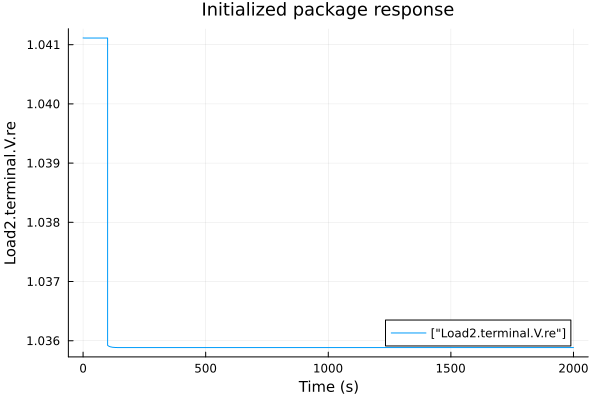

In [7]:
result_columns = names(DataFrame(CSV.File(initialized_resultfile; limit = 0)))
PLOT_VARIABLE in result_columns ||
    error("PLOT_VARIABLE \"$PLOT_VARIABLE\" is not a variable in the simulation result.")
initialized_df = DataFrame(CSV.File(initialized_resultfile; select = ["time", PLOT_VARIABLE]))

p = plot(initialized_df[!, "time"], initialized_df[!, PLOT_VARIABLE], label = [PLOT_VARIABLE])
plot!(p, legend = :bottomright, titlefontsize = 12, labelfontsize = 10)
title!(p, "Initialized package response")
xlabel!(p, "Time (s)")
ylabel!(p, PLOT_VARIABLE)